In [1]:
# Imports
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import warnings
warnings.filterwarnings('ignore')

project_root = '/Users/nicoleotero/Desktop/GLP1 research project/glp1-market-impact-analysis'

# The five companies we're investigating fundamentally
focus_tickers = ['LLY', 'NVO', 'KHC', 'DXCM', 'ISRG']

# FDA event dates
events = {
    'wegovy_approved':   '2021-06-04',
    'mounjaro_approved': '2022-05-13',
    'zepbound_approved': '2023-11-08'
}

print("Libraries loaded successfully")
print(f"Focus companies: {focus_tickers}")

Libraries loaded successfully
Focus companies: ['LLY', 'NVO', 'KHC', 'DXCM', 'ISRG']


In [2]:
# Pull quarterly financials for each company
print("Pulling quarterly revenue data...\n")

revenue_data = {}

for ticker in focus_tickers:
    stock = yf.Ticker(ticker)
    
    # Get quarterly income statement
    quarterly = stock.quarterly_income_stmt
    
    if quarterly is not None and not quarterly.empty:
        # Extract total revenue row
        if 'Total Revenue' in quarterly.index:
            revenue = quarterly.loc['Total Revenue']
            revenue = revenue.sort_index()  # chronological order
            revenue_data[ticker] = revenue
            print(f"{ticker}: {len(revenue)} quarters of revenue data")
            print(f"  Range: {revenue.index[0].date()} to {revenue.index[-1].date()}")
            print(f"  Latest quarterly revenue: ${revenue.iloc[-1]/1e9:.2f}B\n")
        else:
            print(f"{ticker}: Total Revenue not found in financials\n")
    else:
        print(f"{ticker}: No quarterly data available\n")

print("Revenue data pulled successfully!")


Pulling quarterly revenue data...

LLY: 6 quarters of revenue data
  Range: 2024-12-31 to 2026-03-31
  Latest quarterly revenue: $19.80B

NVO: 6 quarters of revenue data
  Range: 2024-12-31 to 2026-03-31
  Latest quarterly revenue: $96.82B

KHC: 6 quarters of revenue data
  Range: 2024-12-31 to 2026-03-31
  Latest quarterly revenue: $6.05B

DXCM: 5 quarters of revenue data
  Range: 2025-03-31 to 2026-03-31
  Latest quarterly revenue: $1.19B

ISRG: 5 quarters of revenue data
  Range: 2025-03-31 to 2026-03-31
  Latest quarterly revenue: $2.77B

Revenue data pulled successfully!


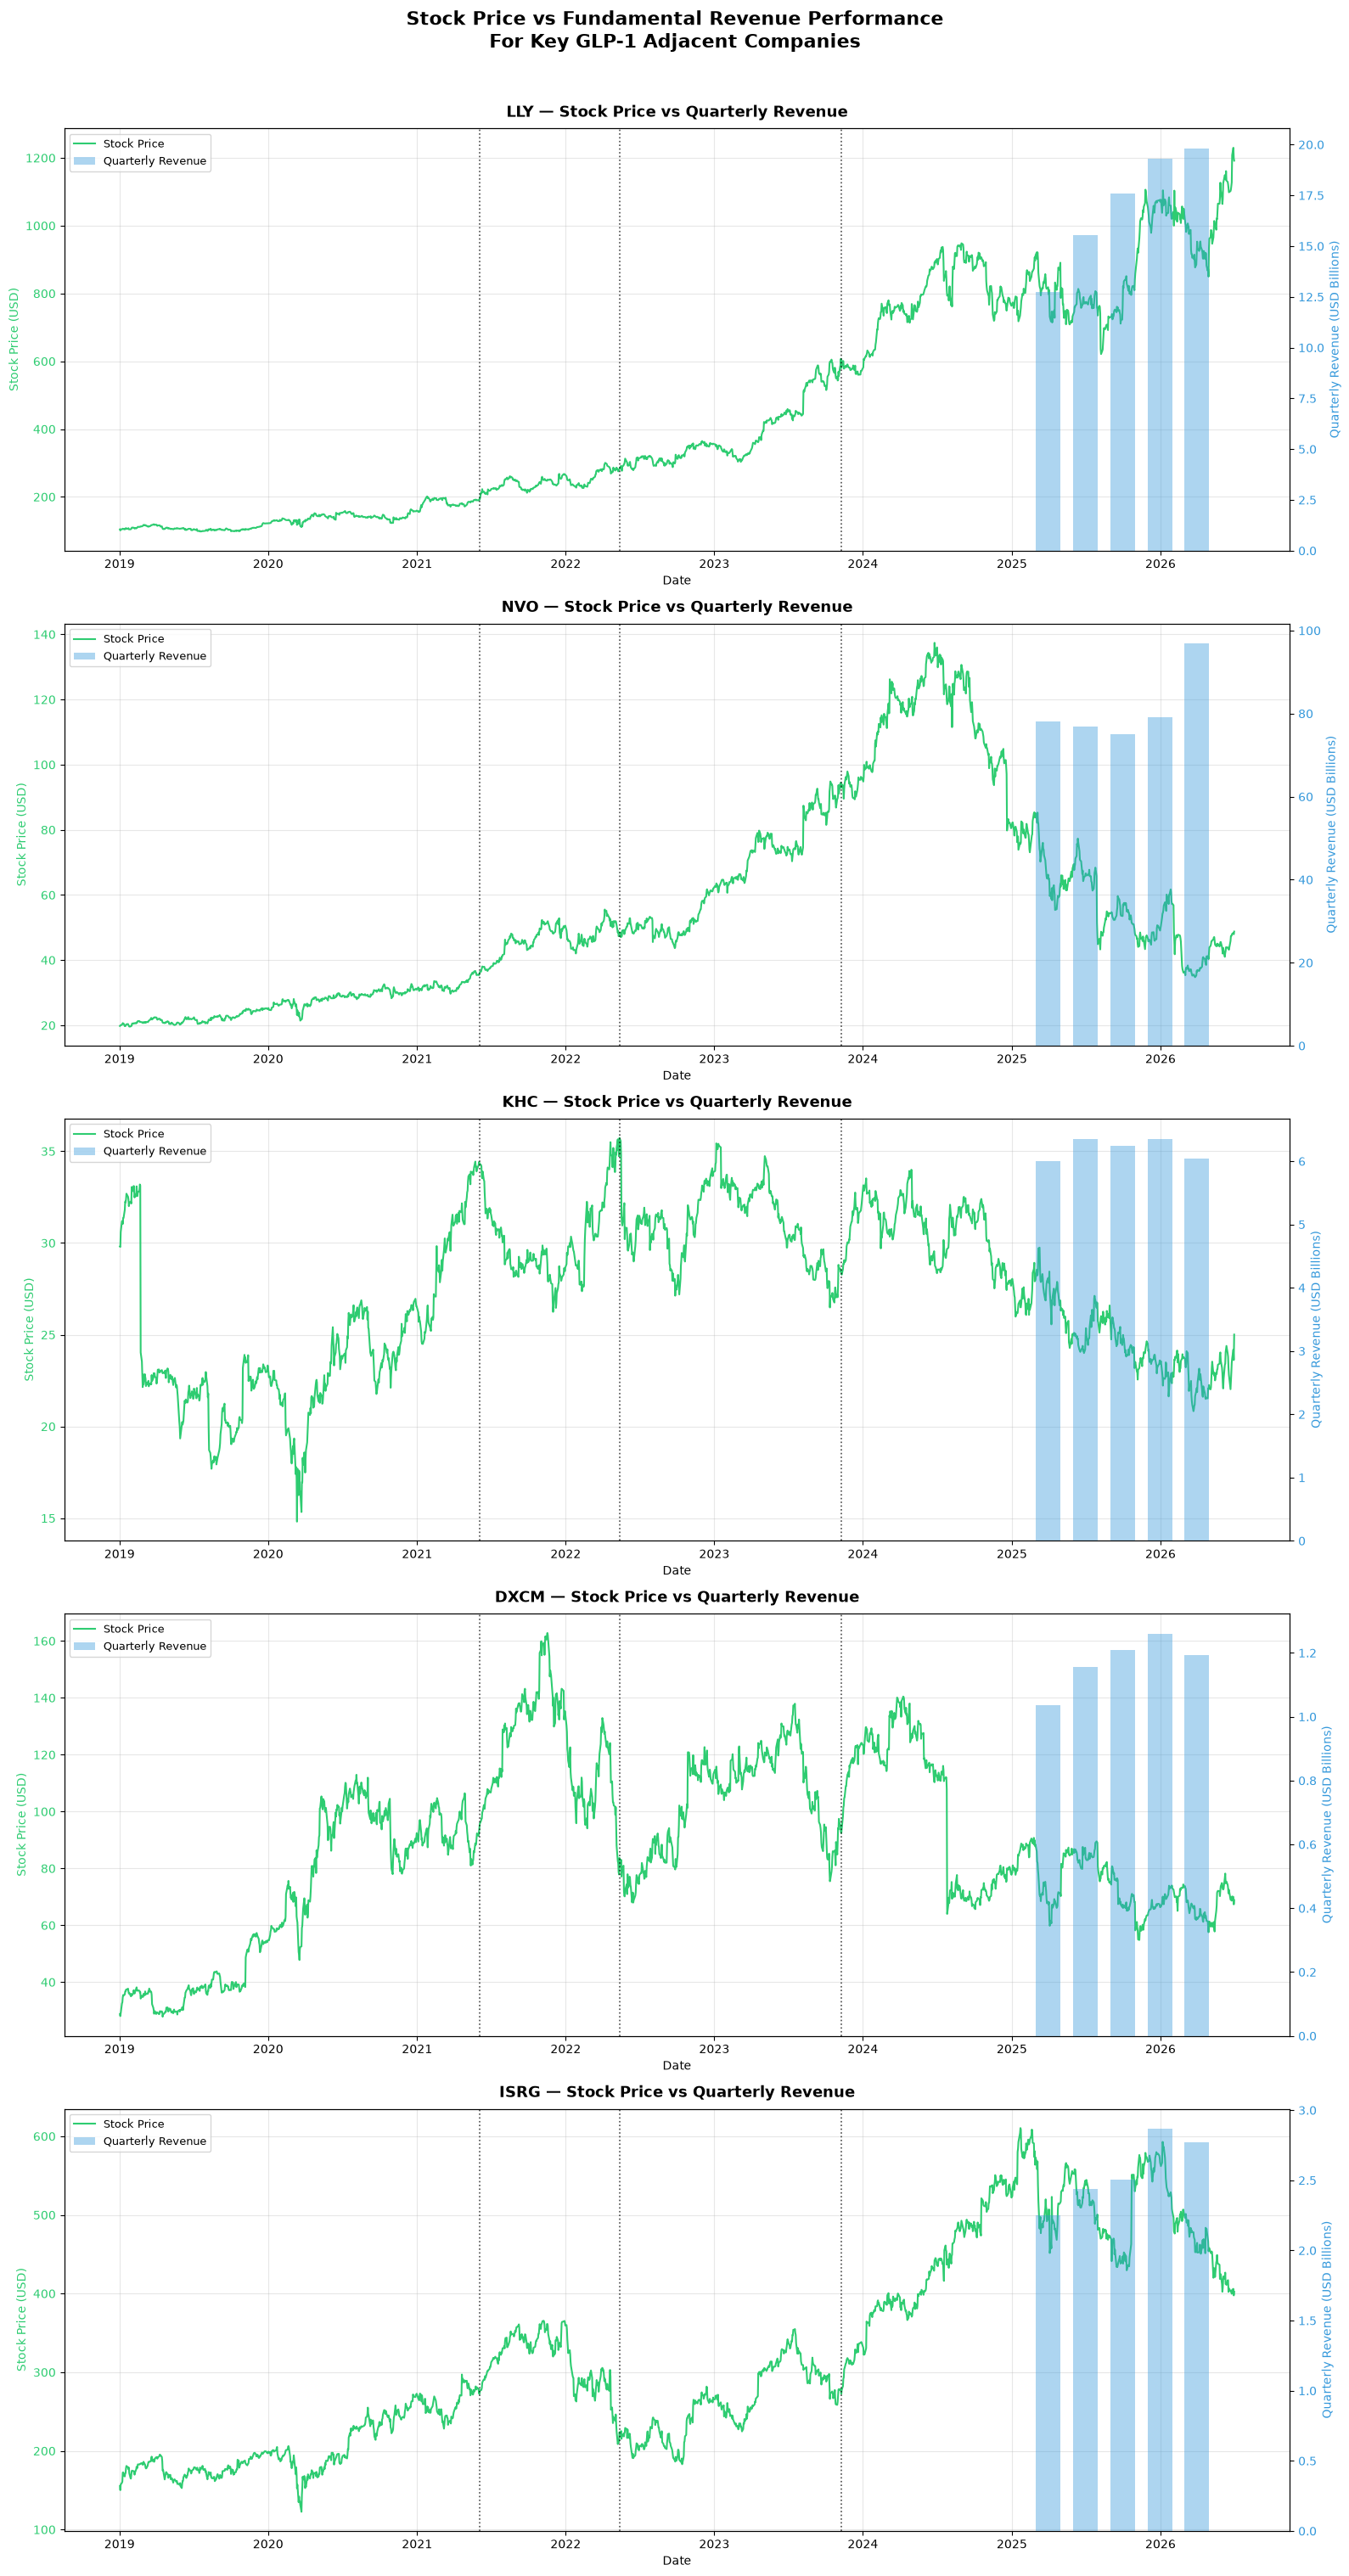

Chart saved!


In [3]:
# Load stock price data
raw_path = os.path.join(project_root, 'data', 'raw', 'close_prices_raw.csv')
prices = pd.read_csv(raw_path, index_col=0, parse_dates=True)

# Create dual axis charts - one per company
fig, axes = plt.subplots(5, 1, figsize=(16, 30))

for idx, ticker in enumerate(focus_tickers):
    ax1 = axes[idx]
    ax2 = ax1.twinx()  # Second y axis for revenue
    
    # Plot stock price
    ax1.plot(prices.index, prices[ticker], 
             color='#2ecc71', linewidth=1.5, label='Stock Price')
    ax1.set_ylabel('Stock Price (USD)', color='#2ecc71', fontsize=10)
    ax1.tick_params(axis='y', labelcolor='#2ecc71')
    
    # Plot revenue as bars
    if ticker in revenue_data:
        rev = revenue_data[ticker]
        ax2.bar(rev.index, rev.values / 1e9,
                width=60, alpha=0.4,
                color='#3498db', label='Quarterly Revenue')
        ax2.set_ylabel('Quarterly Revenue (USD Billions)', 
                      color='#3498db', fontsize=10)
        ax2.tick_params(axis='y', labelcolor='#3498db')
    
    # Add FDA event lines
    for event, date in events.items():
        ax1.axvline(x=pd.Timestamp(date), color='black',
                   linewidth=1.2, linestyle=':', alpha=0.7)
    
    # Labels
    ax1.set_title(f'{ticker} — Stock Price vs Quarterly Revenue', 
                 fontsize=13, fontweight='bold', pad=10)
    ax1.set_xlabel('Date', fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    
    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, 
              loc='upper left', fontsize=9)

plt.suptitle('Stock Price vs Fundamental Revenue Performance\nFor Key GLP-1 Adjacent Companies', 
             fontsize=16, fontweight='bold', y=1.01)

plt.tight_layout()

# Save
os.makedirs(os.path.join(project_root, 'visualizations'), exist_ok=True)
chart_path = os.path.join(project_root, 'visualizations', 'fundamental_vs_price.png')
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

In [5]:
print("=== REVENUE GROWTH vs STOCK PRICE GROWTH ===\n")

results = []

for ticker in focus_tickers:
    if ticker not in revenue_data:
        continue
        
    rev = revenue_data[ticker].dropna()
    
    if len(rev) < 2:
        print(f"{ticker}: Not enough revenue data to calculate growth\n")
        continue
    
    # Use first and last available quarters
    earliest_rev = rev.iloc[0]
    latest_rev = rev.iloc[-1]
    earliest_date = rev.index[0].date()
    latest_date = rev.index[-1].date()
    
    # Only calculate if both values are valid
    if earliest_rev > 0 and latest_rev > 0:
        rev_growth = ((latest_rev - earliest_rev) / earliest_rev * 100)
    else:
        rev_growth = None
    
    # Stock price at Wegovy approval vs today
    wegovy_date = pd.Timestamp('2021-06-04')
    wegovy_idx = prices.index.searchsorted(wegovy_date)
    price_at_wegovy = prices[ticker].iloc[wegovy_idx]
    price_latest = prices[ticker].iloc[-1]
    price_growth = ((price_latest - price_at_wegovy) / price_at_wegovy * 100)
    
    print(f"{ticker}")
    print(f"  Revenue data range: {earliest_date} to {latest_date}")
    print(f"  Earliest quarterly revenue: ${earliest_rev/1e9:.2f}B")
    print(f"  Latest quarterly revenue:   ${latest_rev/1e9:.2f}B")
    
    if rev_growth is not None:
        gap = price_growth - rev_growth
        verdict = 'Overvalued signal' if gap > 50 else \
                  'Undervalued signal' if gap < -50 else \
                  'Fairly priced signal'
        print(f"  Revenue growth:     {rev_growth:+.1f}%")
        print(f"  Stock price growth: {price_growth:+.1f}%")
        print(f"  Gap:                {gap:+.1f}%")
        print(f"  Signal:             {'⚠️  Overvalued' if gap > 50 else '💡 Undervalued' if gap < -50 else '✓ Fairly priced'}\n")
        
        results.append({
            'ticker': ticker,
            'earliest_rev_bn': round(earliest_rev/1e9, 2),
            'latest_rev_bn': round(latest_rev/1e9, 2),
            'revenue_growth_pct': round(rev_growth, 1),
            'stock_price_growth_pct': round(price_growth, 1),
            'gap': round(gap, 1),
            'verdict': verdict
        })
    else:
        print(f"  Revenue growth: insufficient data")
        print(f"  Stock price growth: {price_growth:+.1f}%\n")

if results:
    results_df = pd.DataFrame(results)
    processed_path = os.path.join(project_root, 'data', 'processed')
    results_df.to_csv(os.path.join(processed_path, 'fundamental_vs_price.csv'), index=False)
    print("Results saved!")
    print("\nSummary table:")
    print(results_df[['ticker', 'revenue_growth_pct', 
                       'stock_price_growth_pct', 'gap', 'verdict']].to_string(index=False))

=== REVENUE GROWTH vs STOCK PRICE GROWTH ===

LLY
  Revenue data range: 2025-03-31 to 2026-03-31
  Earliest quarterly revenue: $12.73B
  Latest quarterly revenue:   $19.80B
  Revenue growth:     +55.5%
  Stock price growth: +518.4%
  Gap:                +462.9%
  Signal:             ⚠️  Overvalued

NVO
  Revenue data range: 2025-03-31 to 2026-03-31
  Earliest quarterly revenue: $78.09B
  Latest quarterly revenue:   $96.82B
  Revenue growth:     +24.0%
  Stock price growth: +34.1%
  Gap:                +10.1%
  Signal:             ✓ Fairly priced

KHC
  Revenue data range: 2025-03-31 to 2026-03-31
  Earliest quarterly revenue: $6.00B
  Latest quarterly revenue:   $6.05B
  Revenue growth:     +0.8%
  Stock price growth: -27.1%
  Gap:                -27.9%
  Signal:             ✓ Fairly priced

DXCM
  Revenue data range: 2025-03-31 to 2026-03-31
  Earliest quarterly revenue: $1.04B
  Latest quarterly revenue:   $1.19B
  Revenue growth:     +15.0%
  Stock price growth: -28.1%
  Gap:       